# Playground V1
## 0. Imports and Set-Up:

### 0.1 Imports, Seed-Setting, Plotting-Helper-Function:

In [1]:
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.metrics import pairwise_distances

import numpy as np

In [2]:
import sys
print("Interpreter:", sys.executable)

import carve
print("carve from:", carve.__file__)

import inspect
print("Public names:", [n for n in dir(carve) if not n.startswith("_")])
print("Classes:", [n for n, o in inspect.getmembers(carve, inspect.isclass) if o.__module__.startswith("carve")])
print("Functions:", [n for n, o in inspect.getmembers(carve, inspect.isfunction) if o.__module__.startswith("carve")])

Interpreter: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/.venv/bin/python
carve from: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/__init__.py
Public names: ['CARVE', 'api', 'cluster', 'config', 'grids']
Classes: ['CARVE']
Functions: []


In [3]:
import carve.sim
print("carve.sim from:", carve.sim.__file__)

import inspect
print("Public names:", [n for n in dir(carve.sim) if not n.startswith("_")])
print("Classes:", [n for n, o in inspect.getmembers(carve.sim, inspect.isclass) if o.__module__.startswith("carve.sim")])
print("Functions:", [n for n, o in inspect.getmembers(carve.sim, inspect.isfunction) if o.__module__.startswith("carve.sim")])

carve.sim from: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/sim/__init__.py
Public names: ['ScDesign3Simulator', 'api', 'simulate_clusters']
Classes: ['ScDesign3Simulator']
Functions: ['simulate_clusters']


In [4]:
from carve import CARVE
from carve.config import ValidatorConfig

from carve.sim import simulate_clusters, ScDesign3Simulator

---

## 1. Playground

In [5]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


R callback write-console: Input Data Construction Start
  


  |=======================================================| 100%, Elapsed 00:00


R callback write-console: Input Data Construction End
  
R callback write-console: Start Marginal Fitting
  


  |=======================================================| 100%, Elapsed 01:12


R callback write-console: Marginal Fitting End
  
R callback write-console: Start Copula Fitting
  
R callback write-console: Convert Residuals to Multivariate Gaussian
  


...

R callback write-console: Converting End
  
R callback write-console: Copula group 1 starts
  
R callback write-console: Copula Fitting End
  
R callback write-console: Start Parameter Extraction
  


  |=======================================================| 100%, Elapsed 00:07


R callback write-console: Parameter
Extraction End
  
R callback write-console: Start Generate New Data
  
R callback write-console: Use Copula to sample a multivariate quantile matrix
  
R callback write-console: Sample Copula group 1 starts
  


  |=======================================================| 100%, Elapsed 00:00


R callback write-console: New Data Generating End
  


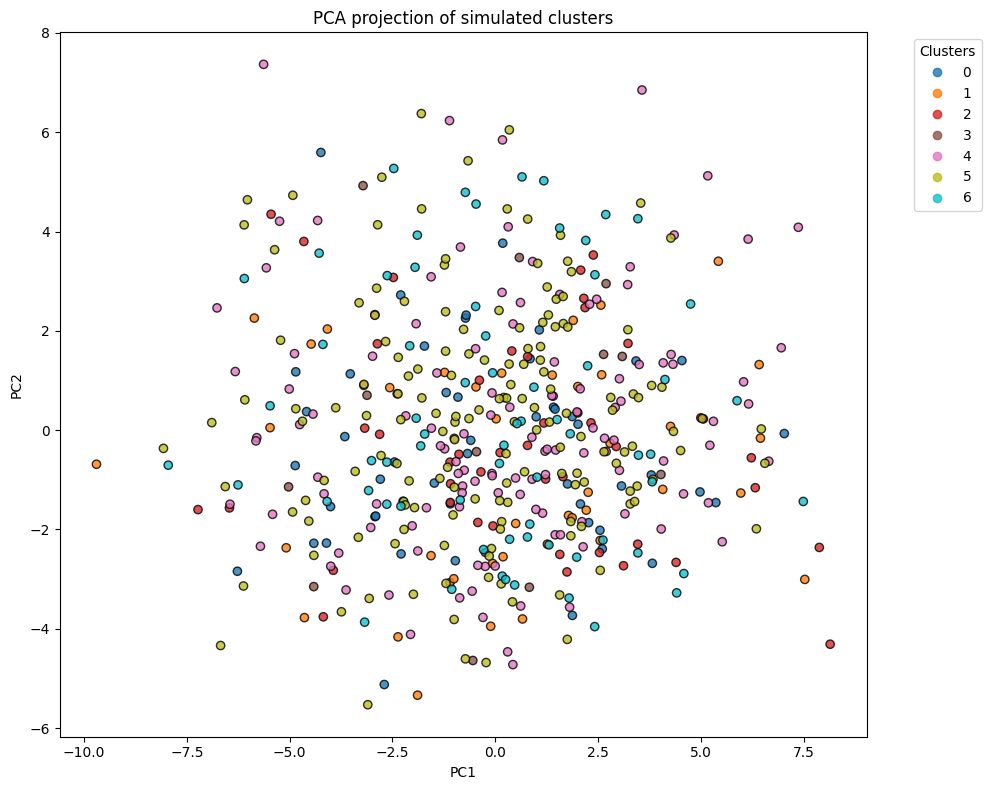

In [8]:
scsim = ScDesign3Simulator(
    reference_sce_rds="../data/refs/zeisel_brain_ref.sce.rds",
    assay_use="counts",
    label_col="cell_type",
    family="nb", copula="gaussian",
    n_cores=10,
    n_genes_fit=3000,
    min_detect_rate=0.01
)

X, y = scsim.simulate(
    noise_genes=0.001,
    k=7,
    seed=0,
    n_total=500,
    p=200,
    plotting=True
)

In [6]:
# f=8

# X, y, _ = simulate_clusters(
#     n_total=1000, p=4, k=4,
#     balanced=False,
#     cluster_size_dirichlet_alpha=0.15,  # strong imbalance
#     cluster_scale=[f * s for s in [0.5, 0.8, 1.4, 2.0]],
#     corr_type="ar1", corr_strength=0.75,  # correlated features
#     distribution="t", t_df=3,             # heavier tails
#     centroid_method="min_dist", min_center_dist=6.0,
#     center_box=10.0,
#     random_state=33
# )


In [7]:
# cfg1 = ValidatorConfig(
#     X=X,
#     ref_labels=y
# )

# val1 = CARVE(cfg1)
# val1.validate(random_state=42)

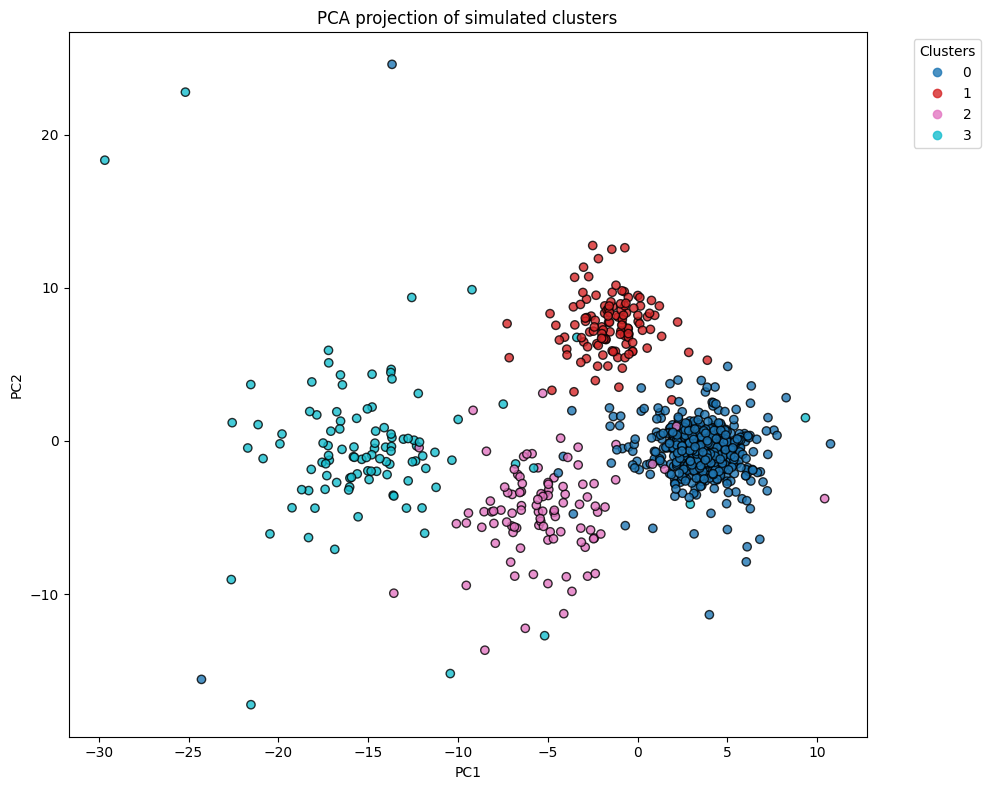

In [8]:
f=1

X, y, _ = simulate_clusters(
    n_total=1000, p=2, k=4,
    balanced=False,
    cluster_size_dirichlet_alpha=0.15,  # strong imbalance
    # cluster_scale=[f * s for s in [1, 2]],
    cluster_scale=[f * s for s in [1, 2, 4, 8]],
    # cluster_scale=[f * s for s in [1, 2, 4, 8]],
    distribution="t",
    centroid_method="min_dist", min_center_dist=0.0,
    nonlinear=False, embed_method="fourier", embed_dim=20, embed_param=2.0,
    center_box=10,
    random_state=5
)


In [11]:
# D2 = pairwise_distances(X, metric='sqeuclidean')
# median_d2 = np.median(D2[np.triu_indices_from(D2, k=1)])
# gamma0 = 1.0 / (2.0 * median_d2) if median_d2 > 0 else 1.0
# gamma0 = [gamma0]
# gamma0 = np.logspace(np.log10(gamma0) - 1, np.log10(gamma0) + 1, num=3)

ks = list(range(2, 9))
# ks = list(range(3, 6))
    
model_grids = [
    # (KMeans, {"n_clusters": ks}),
    (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward"]}),
    # (SpectralClustering, {"n_clusters": ks, "gamma": gamma0})
]

cfg1 = ValidatorConfig(
    X=X,
    ref_labels=y, 
    model_grids=model_grids,
)

val1 = CARVE(cfg1)
val1.validate(random_state=42)

Grid configs:   0%|          | 0/7 [00:00<?, ?it/s]

In [12]:
val1.plot_global(rule='max')

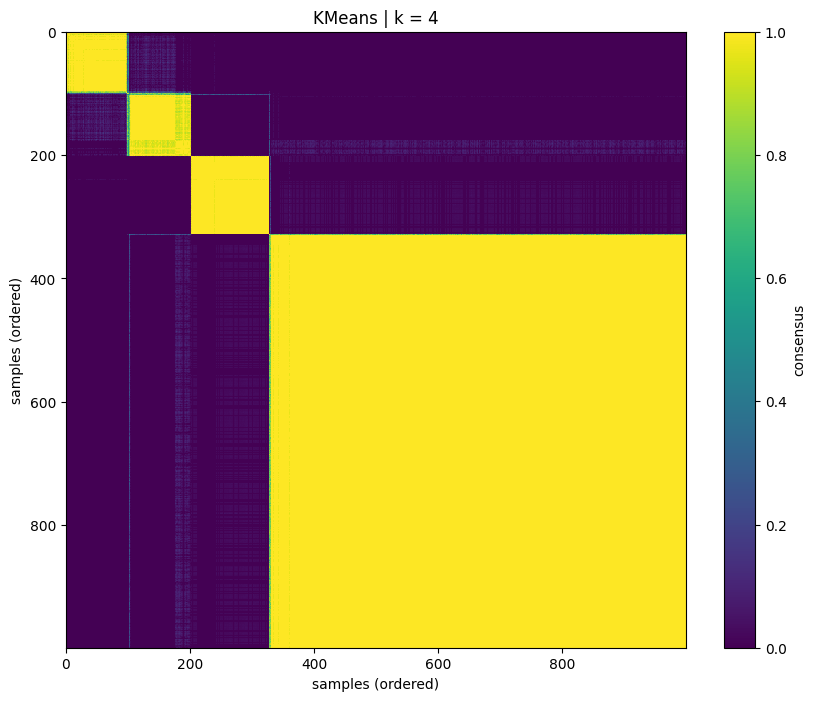

In [16]:
val1.plot_consensus_matrix(measure='s', rule='1se')

In [17]:
val1.plot_clustering(rule='1se')

FigureWidget({
    'data': [{'customdata': {'bdata': ('AAAAAAAA8D8AAAAAAAAAAAFMrQFuiu' ... 'nb6BVx7z/CJq6rIyjvPwAAAAAAAPA/'),
                             'dtype': 'f8',
                             'shape': '672, 5'},
              'hovertemplate': ('sample %{customdata[0]}<br>clu' ... 'tomdata[4]:.4f}<extra></extra>'),
              'legendgroup': 'cluster-0',
              'marker': {'line': {'width': 0},
                         'opacity': 1.0,
                         'size': {'bdata': ('bu/zl/KNKkBzfqI30LsqQCWPBt/xti' ... 'zJYUeLKkCPvxYnjY8qQGYg0N5bfCpA'),
                                  'dtype': 'f8'}},
              'mode': 'markers',
              'name': 'cluster 0',
              'showlegend': True,
              'type': 'scatter',
              'uid': '70bbb11c-af43-437b-a879-a81be9c77d90',
              'x': {'bdata': ('iqENinY/DkByRZsue/IMQHpN915PUw' ... 'vG6NEKDUC7pGj9DZMVQFvJQ87wMBVA'),
                    'dtype': 'f8'},
              'xaxis': 'x',
              'y':

---

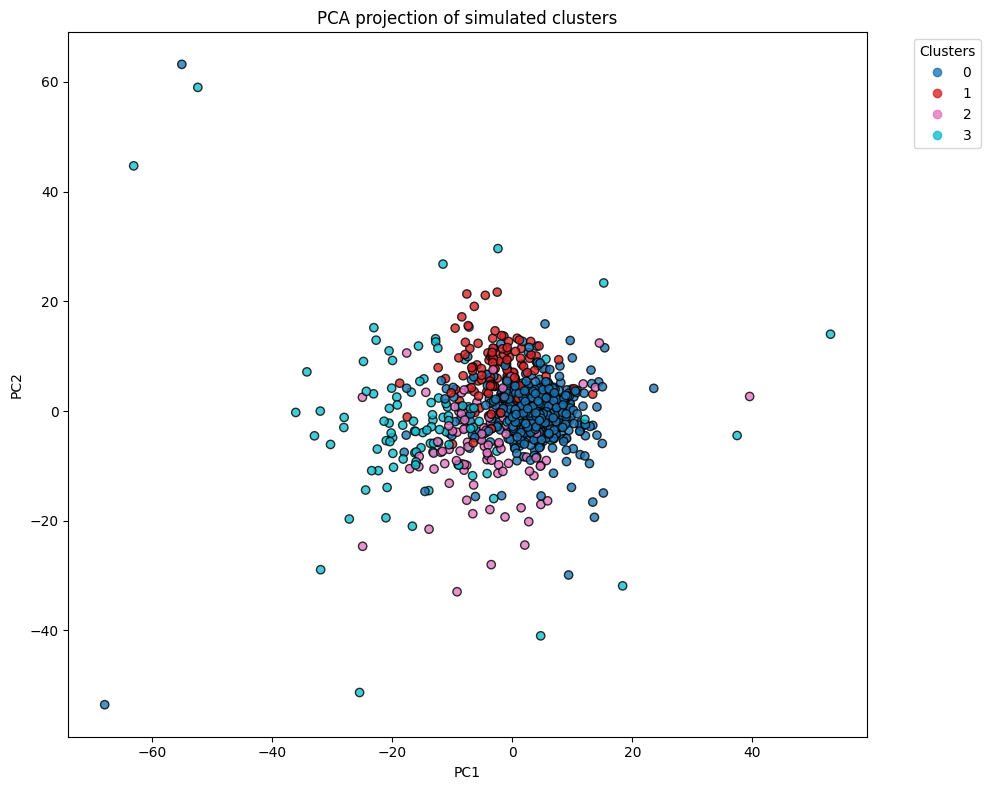

In [18]:
f=8

X_difficult, y_difficult, _ = simulate_clusters(
    n_total=1000, p=2, k=4,
    balanced=False,
    cluster_size_dirichlet_alpha=0.15,  # strong imbalance
    # cluster_scale=[f * s for s in [1, 2]],
    cluster_scale=[f * s for s in [1, 2, 4, 8]],
    # cluster_scale=[f * s for s in [1, 2, 4, 8]],
    distribution="t",
    centroid_method="min_dist", min_center_dist=0.0,
    nonlinear=False, embed_method="fourier", embed_dim=20, embed_param=2.0,
    center_box=10,
    random_state=5
)


Grid configs:   0%|          | 0/7 [00:00<?, ?it/s]

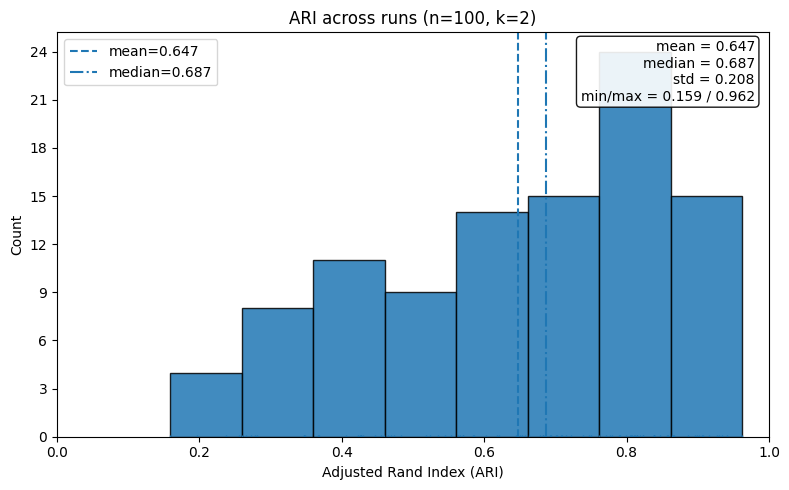

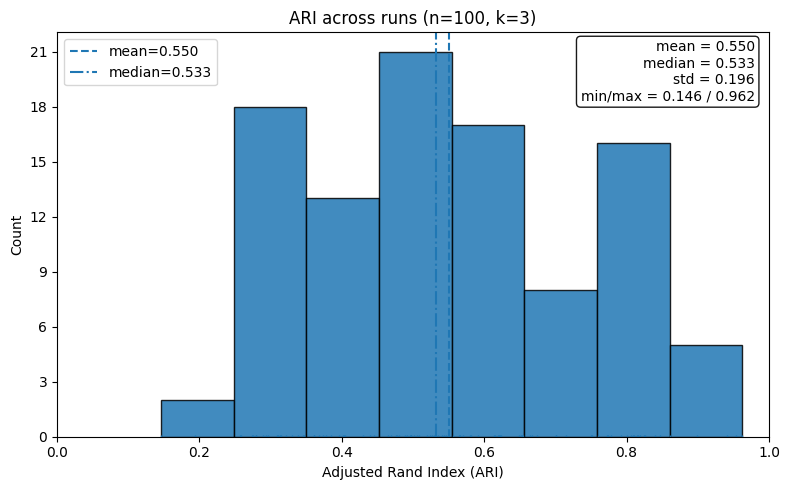

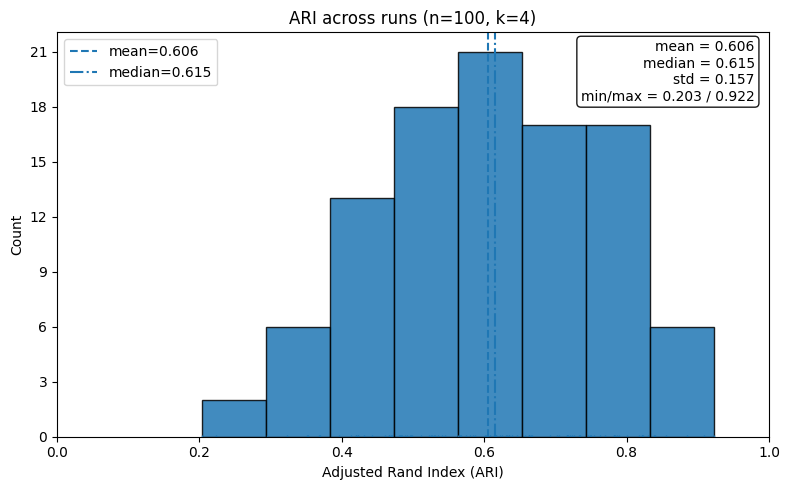

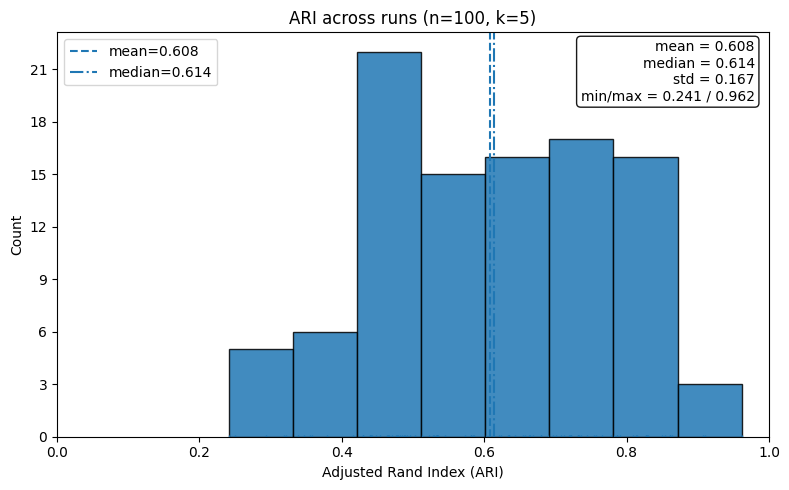

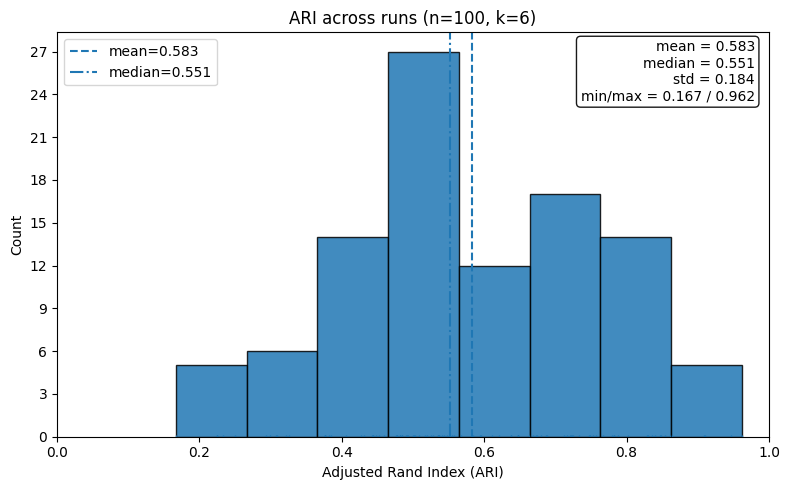

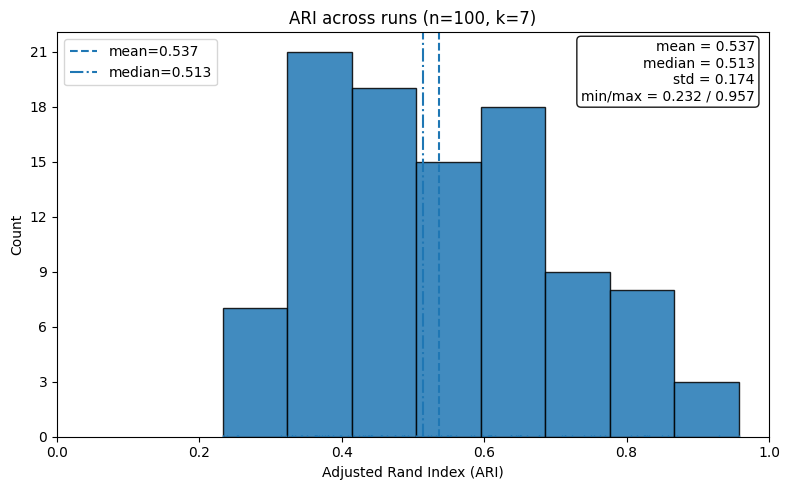

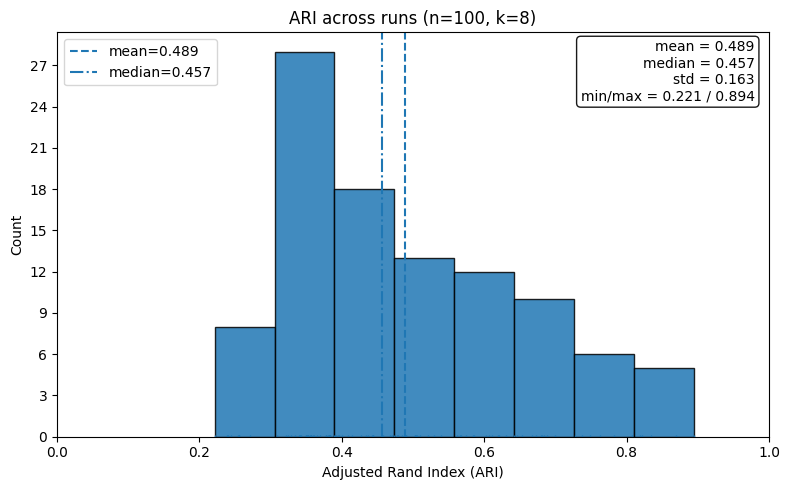

In [19]:
ks = list(range(2, 9))
    
model_grids = [
    # (KMeans, {"n_clusters": ks}),
    (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward"]}),
    # (SpectralClustering, {"n_clusters": ks, "gamma": gamma0})
]

cfg1 = ValidatorConfig(
    X=X_difficult,
    ref_labels=y_difficult, 
    model_grids=model_grids,
)

val1 = CARVE(cfg1)
val1.validate(random_state=42)

In [20]:
val1.plot_global(measure='stability', rule='1se')

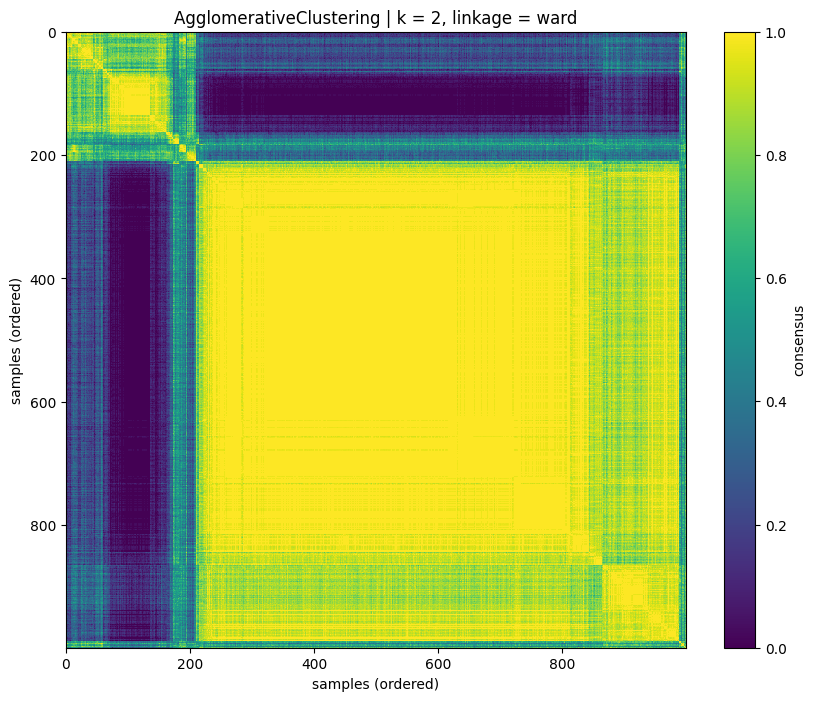

In [21]:
val1.plot_consensus_matrix(measure='s', rule='1se')

In [22]:
val1.plot_clustering(measure='s', rule='1se')

FigureWidget({
    'data': [{'customdata': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAOAEt6Qbm8' ... 'JJKMk/+JrlF9yAwz/SJ33SJ33iPw=='),
                             'dtype': 'f8',
                             'shape': '217, 5'},
              'hovertemplate': ('sample %{customdata[0]}<br>clu' ... 'tomdata[4]:.4f}<extra></extra>'),
              'legendgroup': 'cluster-0',
              'marker': {'line': {'width': 0},
                         'opacity': 0.3,
                         'size': {'bdata': ('idmCYcxiG0CXt3CEvPsgQFxvJJAmxB' ... 'v/PdISQJUOUvREnShAxM7B6CjpHEA='),
                                  'dtype': 'f8'}},
              'mode': 'markers',
              'name': 'cluster 0',
              'showlegend': True,
              'type': 'scatter',
              'uid': '74318d22-66d7-4a9f-9a0f-a72fe373bb0c',
              'x': {'bdata': ('oGXSFsHDEMCEbMhPFU0awLi0EiiA3R' ... 'aWuQsgwK1wvYu9UTjAuerhYJCKGcA='),
                    'dtype': 'f8'},
              'xaxis': 'x',
              'y':

---

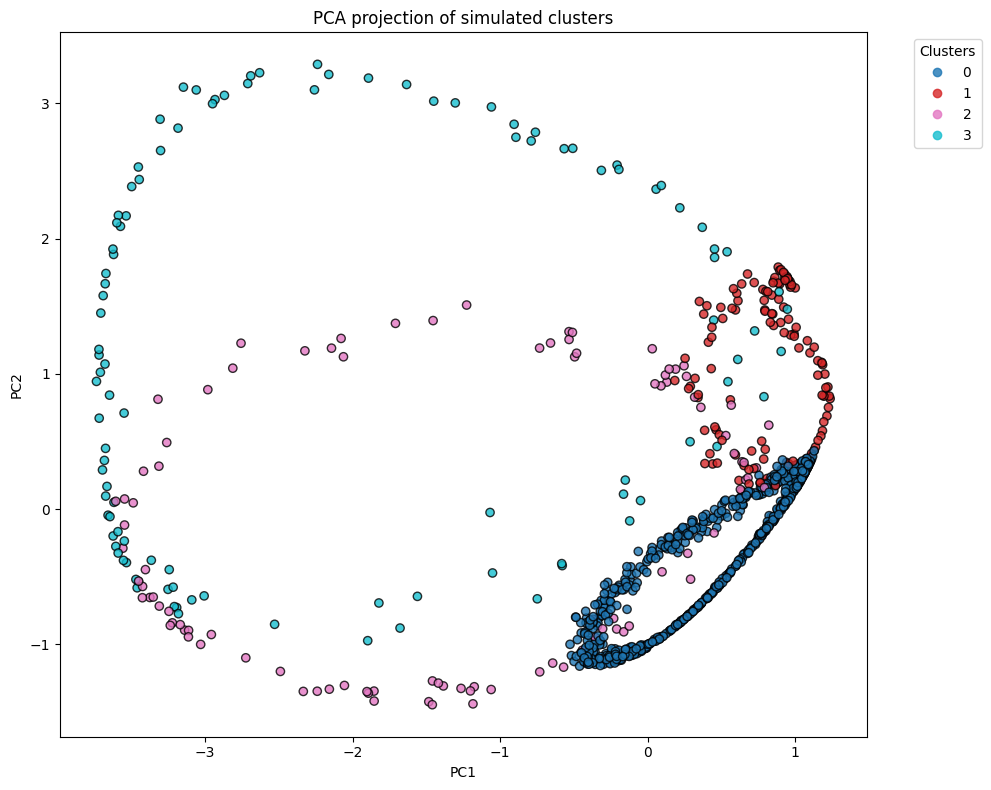

In [23]:
f=8

X, y, _ = simulate_clusters(
    n_total=1000, p=2, k=4,
    balanced=False,
    cluster_size_dirichlet_alpha=0.15,  # strong imbalance
    # cluster_scale=[f * s for s in [1, 2]],
    cluster_scale=[f * s for s in [1, 2, 4, 8]],
    # cluster_scale=[f * s for s in [1, 2, 4, 8]],
    distribution="circles",
    centroid_method="min_dist", min_center_dist=0.0,
    nonlinear=True, embed_method="fourier", embed_dim=20, embed_param=2.0,
    center_box=10,
    random_state=5
)


Grid configs:   0%|          | 0/7 [00:00<?, ?it/s]

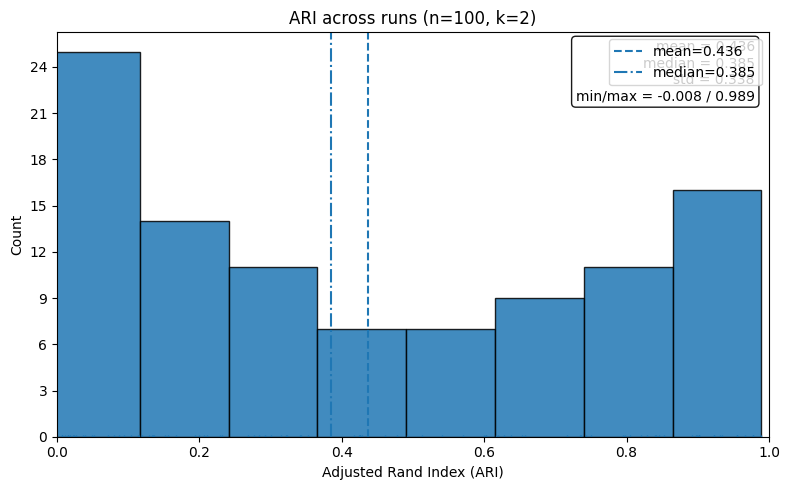

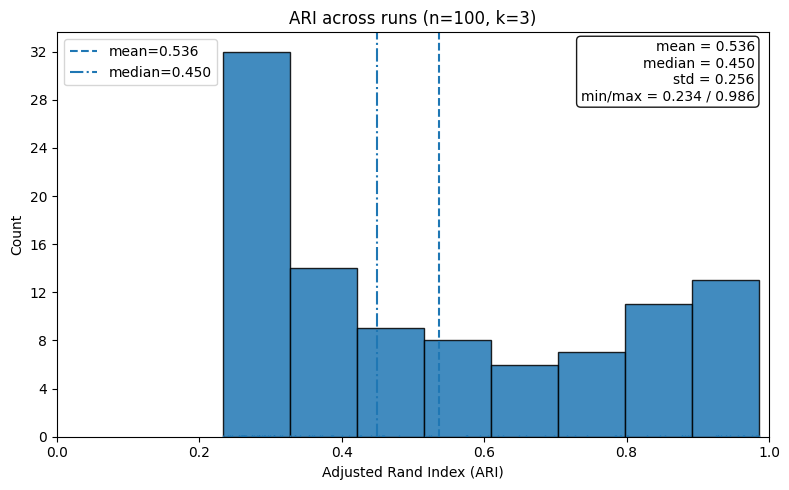

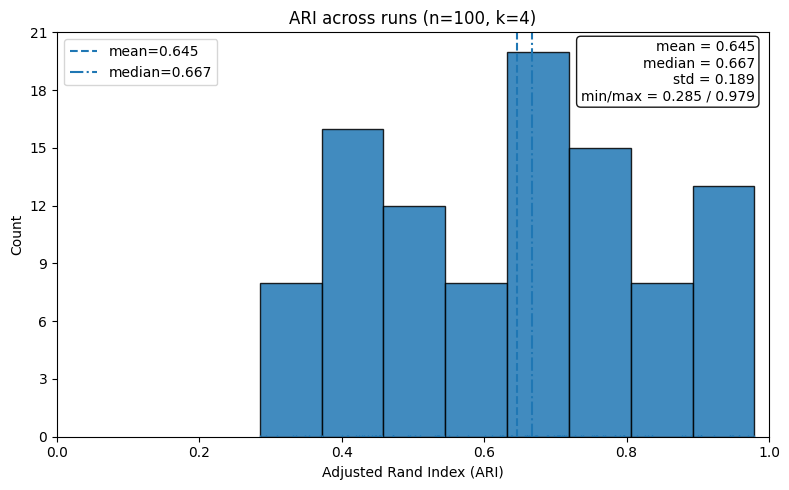

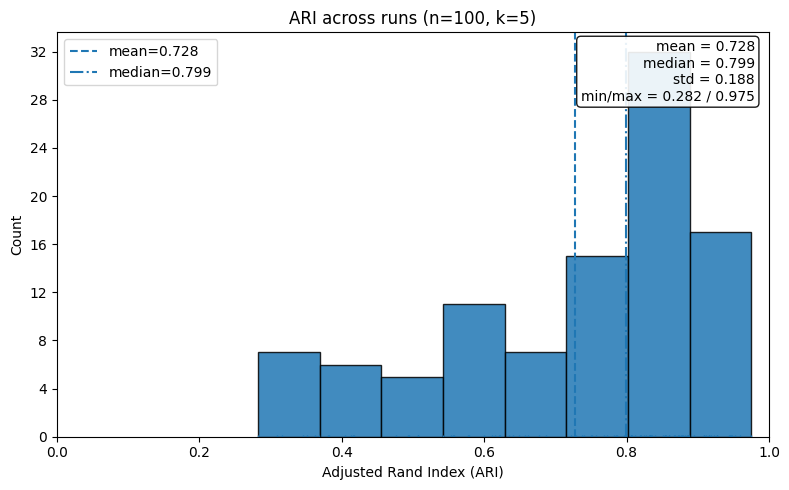

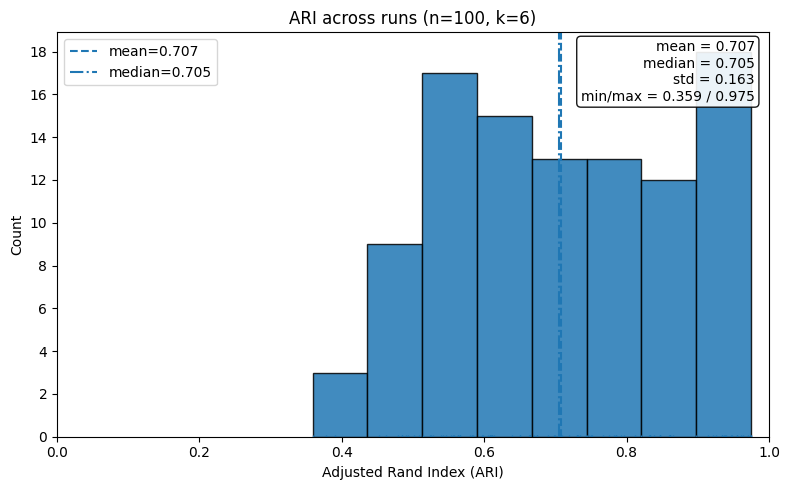

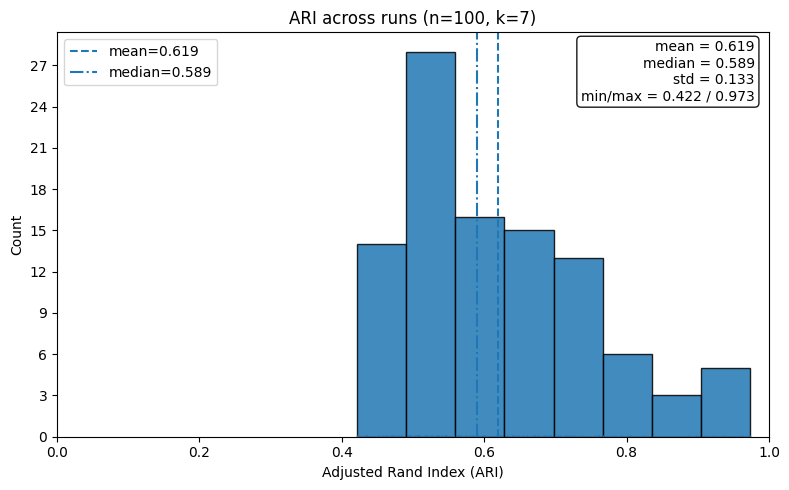

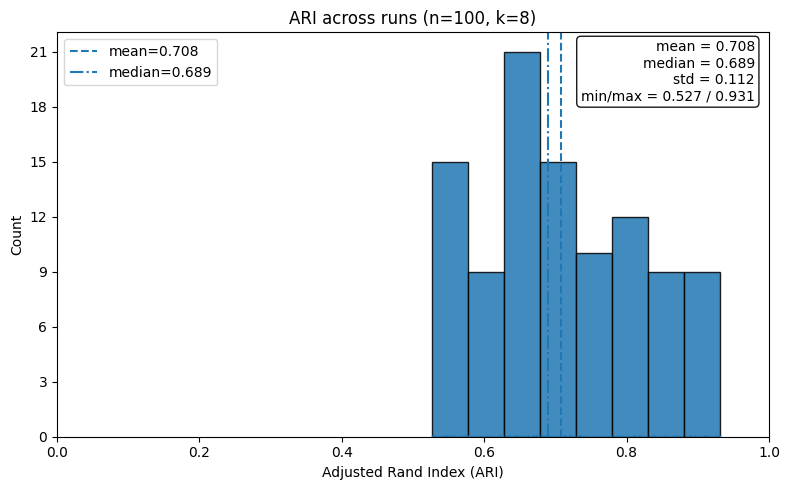

In [26]:
D2 = pairwise_distances(X, metric='sqeuclidean')
median_d2 = np.median(D2[np.triu_indices_from(D2, k=1)])
gamma0 = 1.0 / (2.0 * median_d2) if median_d2 > 0 else 1.0
gamma0 = [gamma0]

ks = list(range(2, 9))
    
model_grids = [
    # (KMeans, {"n_clusters": ks}),
    # (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward"]}),
    (SpectralClustering, {"n_clusters": ks, "affinity": ['nearest_neighbors'], 'n_neighbors': [20]})
]

cfg1 = ValidatorConfig(
    X=X,
    ref_labels=y, 
    model_grids=model_grids,
)

val1 = CARVE(cfg1)
val1.validate(random_state=42)

In [27]:
val1.plot_global(measure='stability', rule='1se')

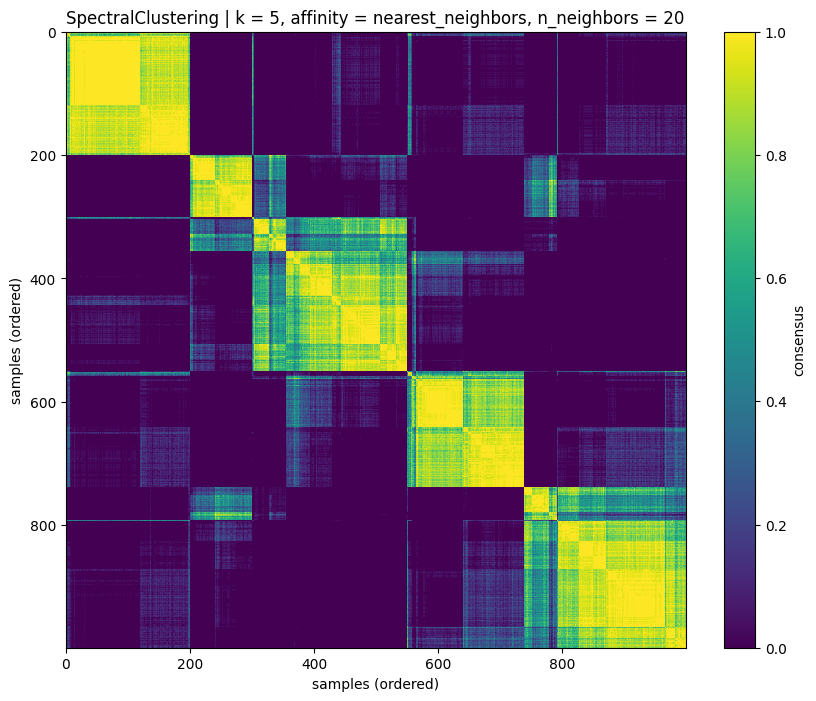

In [29]:
val1.plot_consensus_matrix(measure='s', rule='1se')

In [32]:
val1.plot_clustering(measure='s', rule='1se')

FigureWidget({
    'data': [{'customdata': {'bdata': ('AAAAAAAACEAAAAAAAAAAABcMRLBVQe' ... 'M1shvp6T+9Gs27ZfboP8L5GJyPwek/'),
                             'dtype': 'f8',
                             'shape': '228, 5'},
              'hovertemplate': ('sample %{customdata[0]}<br>clu' ... 'tomdata[4]:.4f}<extra></extra>'),
              'legendgroup': 'cluster-0',
              'marker': {'line': {'width': 0},
                         'opacity': 0.3874404586041047,
                         'size': {'bdata': ('mytD2RCuJ0BQem3zvlcnQD4bxY4IsC' ... '7CWS0sJ0A07SVfGLImQOWd8r+iXSZA'),
                                  'dtype': 'f8'}},
              'mode': 'markers',
              'name': 'cluster 0',
              'showlegend': True,
              'type': 'scatter',
              'uid': '3cd811c8-51f7-4f13-b6ab-97273ec2ea62',
              'x': {'bdata': ('qJGlNEQ38D/C7RgTK6rwP/KDQYfDrP' ... 'TGh03G7z/CPxJOs2rxPyCIt4aYze0/'),
                    'dtype': 'f8'},
              'xaxis': 'x',
   